# 22 — Gateway Decision Analysis (Camargo Helpdesk)

For each gateway (activity with >1 observed successor), train:

1. **LSTM Surrogate** — target = Camargo's predicted next activity.
2. **Ground Truth** — target = actual next activity from the event log.

Same stratified 60/20/20 split, same C4.5 classifier and depth sweep as the henryk notebook, but with predictions coming from the Camargo `FullShared_Join_LSTM`.

In [ ]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir() and (_current / 'encoded_data').is_dir():
        break
    _current = _current.parent
_camargo_dir = _current / 'src' / 'interpretability' / 'notebooks' / 'camargo'
for p in [_current, _current / 'src', _camargo_dir]:
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))

import _camargo_utils as utils
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split

from src.interpretability.surrogate.c45_tree import C45Classifier

SPEC = utils.HELPDESK_SHAREDCAT_ROLES_NGRAM
model = utils.load_camargo_model(_current, SPEC)
dataset = utils.load_test_dataset(_current, SPEC)
window = SPEC.ngram_size or utils.compute_window(dataset)
predictor = utils.CamargoPredictor(model, SPEC, window)
eos_idx = predictor.eos_idx
idx_to_name = predictor.idx_to_name
# Resource/Role label vocab so categorical positional features stay categorical
# in the surrogate trees (don't let C4.5 split a Role on '> 2.5').
res_idx_to_name = {v: k for k, v in model.data_set_categories[0][1][2].items()}
ACT_IDX = SPEC.cat_indices[0]  # position of Activity/concept:name in henryk cats
RES_IDX = SPEC.cat_indices[1]  # Resource/org:resource
CET_IDX = SPEC.num_indices[0]  # case_elapsed_time
print(f'{SPEC.name} | window={window} | vocab={predictor.n_classes}')

## Build DFG and identify qualifying gateways

In [2]:
MIN_CASES = 4
MIN_BRANCH = 1
MIN_SAMPLES_LEAF = 20
ACTIVITY_WINDOW = 10  # positional history depth

# Unique cases (longest trace per case_id)
cases = {}
for i in range(len(dataset)):
    cat_t, num_t, case_id = dataset[i]
    trace_len = int((cat_t[0] != 0).sum().item())
    if case_id not in cases or trace_len > cases[case_id][1]:
        cases[case_id] = (i, trace_len)
print(f'{len(cases)} unique cases')

# DFG over ground-truth transitions
dfg = {}
for case_id, (ds_idx, trace_len) in cases.items():
    cat_full = dataset[ds_idx][0]
    acts = cat_full[ACT_IDX].tolist()
    nonzero = [i for i, a in enumerate(acts) if a != 0]
    if not nonzero:
        continue
    start = nonzero[0]
    useful_len = len(nonzero)
    while useful_len > 0 and acts[start + useful_len - 1] == eos_idx:
        useful_len -= 1
    # Append synthetic 'EOS' so case-end transitions land in the DFG
    names = [idx_to_name.get(acts[start + k]) for k in range(useful_len)] + ['EOS']
    for k in range(len(names) - 1):
        edge = (names[k], names[k + 1])
        dfg[edge] = dfg.get(edge, 0) + 1

successors_map = {}
for (src, tgt), count in dfg.items():
    successors_map.setdefault(src, {})[tgt] = count

decision_points = {act: succs for act, succs in successors_map.items() if len(succs) > 1}
print(f'{len(decision_points)} gateways')
for act, succs in sorted(decision_points.items(), key=lambda x: -sum(x[1].values())):
    total = sum(succs.values())
    branches = ', '.join(f'{s} ({c})' for s, c in sorted(succs.items(), key=lambda x: -x[1]))
    print(f'  {act} ({total}): {branches}')

916 unique cases
9 gateways
  Take in charge ticket (996): Resolve ticket (717), Wait (243), Take in charge ticket (16), Require upgrade (12), Create SW anomaly (7), Schedule intervention (1)
  Assign seriousness (995): Take in charge ticket (837), Assign seriousness (96), Resolve ticket (50), Wait (11), Require upgrade (1)
  Resolve ticket (988): Closed (910), Resolve ticket (50), Take in charge ticket (26), RESOLVED (1), EOS (1)
  Closed (916): EOS (910), Closed (5), Take in charge ticket (1)
  Wait (283): Resolve ticket (153), Take in charge ticket (99), Wait (24), EOS (4), Require upgrade (1), Create SW anomaly (1), Assign seriousness (1)
  Insert ticket (28): Assign seriousness (26), Wait (2)
  Require upgrade (21): Resolve ticket (9), Require upgrade (4), Wait (3), Create SW anomaly (3), EOS (1), Take in charge ticket (1)
  Create SW anomaly (12): Resolve ticket (8), Require upgrade (2), Create SW anomaly (1), Resolve SW anomaly (1)
  Resolve SW anomaly (2): Resolve SW anomaly (1

## Collect per-gateway prefixes + LSTM predictions

In [3]:
def extract_features(acts_history, res_history, cet_history, prefix_len):
    """Positional categorical features for the last ACTIVITY_WINDOW events plus prefix_length."""
    feats = {'prefix_length': prefix_len}
    for w in range(1, ACTIVITY_WINDOW + 1):
        pos = prefix_len - w
        feats[f'activity_pos_{-w}'] = idx_to_name.get(acts_history[pos]) if pos >= 0 else '<pad>'
        feats[f'resource_pos_{-w}'] = res_idx_to_name.get(int(res_history[pos]), str(int(res_history[pos]))) if pos >= 0 else '<pad>'
        feats[f'cet_pos_{-w}'] = float(cet_history[pos]) if pos >= 0 else float('nan')
    return feats


gateway_data = {}
for gateway_act, succs in decision_points.items():
    qualifying = [s for s, c in succs.items() if c >= MIN_BRANCH]
    if len(qualifying) < 2 or sum(succs.values()) < MIN_CASES:
        continue

    rows_X, y_actual, y_lstm = [], [], []
    for case_id, (ds_idx, trace_len) in cases.items():
        cat_full, num_full, _ = dataset[ds_idx]
        acts_raw = cat_full[ACT_IDX].tolist()
        nonzero = [i for i, a in enumerate(acts_raw) if a != 0]
        if not nonzero:
            continue
        start = nonzero[0]
        useful_len = len(nonzero)
        while useful_len > 0 and acts_raw[start + useful_len - 1] == eos_idx:
            useful_len -= 1

        # Iterate up to and including the last real activity (next = EOS for k == useful_len - 1)
        for k in range(useful_len):
            if idx_to_name.get(acts_raw[start + k]) != gateway_act:
                continue
            prefix_len = k + 1
            if k < useful_len - 1:
                next_name = idx_to_name.get(acts_raw[start + prefix_len])
            else:
                next_name = 'EOS'
            # build prefix window for LSTM
            cats_win, nums_win = utils.make_prefix_window(
                cat_full, num_full, start=start, prefix_length=prefix_len,
                window=window, spec=SPEC,
            )
            pred_idx, _ = predictor.predict_batch(cats_win, nums_win)
            pred_name = idx_to_name.get(int(pred_idx.item()), f'<{int(pred_idx.item())}>')
            # feature row
            acts_history = [acts_raw[start + j] for j in range(prefix_len)]
            res_history = cat_full[RES_IDX].tolist()
            res_history = [res_history[start + j] for j in range(prefix_len)]
            cet_history = num_full[CET_IDX].tolist()
            cet_history = [cet_history[start + j] for j in range(prefix_len)]
            rows_X.append(extract_features(acts_history, res_history, cet_history, prefix_len))
            y_actual.append(next_name)
            y_lstm.append(pred_name)

    if len(rows_X) < MIN_CASES:
        continue

    X = pd.DataFrame(rows_X)
    y_actual = np.array(y_actual)
    y_lstm = np.array(y_lstm)
    lstm_acc = float((y_lstm == y_actual).mean())
    print(f'{gateway_act}: N={len(X)}, LSTM acc={lstm_acc:.3f}, actual branches={len(set(y_actual))}, LSTM branches={len(set(y_lstm))}')
    gateway_data[gateway_act] = {'X': X, 'y_actual': y_actual, 'y_lstm': y_lstm, 'successors': succs}

print(f'\n{len(gateway_data)} qualifying gateways: {list(gateway_data.keys())}')

Assign seriousness: N=995, LSTM acc=0.840, actual branches=5, LSTM branches=2
Take in charge ticket: N=996, LSTM acc=0.713, actual branches=6, LSTM branches=3
Resolve ticket: N=988, LSTM acc=0.922, actual branches=5, LSTM branches=2
Closed: N=916, LSTM acc=0.993, actual branches=3, LSTM branches=1
Wait: N=283, LSTM acc=0.636, actual branches=7, LSTM branches=4
Insert ticket: N=28, LSTM acc=0.929, actual branches=2, LSTM branches=1
Require upgrade: N=21, LSTM acc=0.381, actual branches=6, LSTM branches=2
Create SW anomaly: N=12, LSTM acc=0.583, actual branches=4, LSTM branches=3

8 qualifying gateways: ['Assign seriousness', 'Take in charge ticket', 'Resolve ticket', 'Closed', 'Wait', 'Insert ticket', 'Require upgrade', 'Create SW anomaly']


## Train surrogate + ground-truth trees per gateway

In [4]:
def select_depth(X_tr, y_tr, X_val, y_val, cat_feats, depths=(3, 4, 5, 6, 7, 8)):
    best = None
    for d in depths:
        clf = C45Classifier(max_depth=d, min_samples_leaf=MIN_SAMPLES_LEAF, class_weight='balanced', random_state=42)
        clf.fit(X_tr, y_tr, categorical_features=cat_feats)
        val = clf.score(X_val, y_val)
        if best is None or val > best['val'] + 0.02:
            best = {'depth': d, 'val': val, 'clf': clf}
    return best['clf']


gateway_results = {}
for gw, gd in gateway_data.items():
    X, y_actual, y_lstm = gd['X'], gd['y_actual'], gd['y_lstm']
    cat_cols = [c for c in X.columns if X[c].dtype == 'object']

    try:
        X_tv, X_te, y_lstm_tv, y_lstm_te, y_act_tv, y_act_te = train_test_split(
            X, y_lstm, y_actual, test_size=0.2, random_state=42, stratify=y_actual)
    except ValueError:
        X_tv, X_te, y_lstm_tv, y_lstm_te, y_act_tv, y_act_te = train_test_split(
            X, y_lstm, y_actual, test_size=0.2, random_state=42)
    try:
        X_tr, X_val, y_lstm_tr, y_lstm_val, y_act_tr, y_act_val = train_test_split(
            X_tv, y_lstm_tv, y_act_tv, test_size=0.25, random_state=42, stratify=y_act_tv)
    except ValueError:
        X_tr, X_val, y_lstm_tr, y_lstm_val, y_act_tr, y_act_val = train_test_split(
            X_tv, y_lstm_tv, y_act_tv, test_size=0.25, random_state=42)

    clf_lstm = select_depth(X_tr, y_lstm_tr, X_val, y_lstm_val, cat_cols)
    clf_gt = select_depth(X_tr, y_act_tr, X_val, y_act_val, cat_cols)
    fidelity = clf_lstm.score(X_te, y_lstm_te)
    gt_acc = clf_gt.score(X_te, y_act_te)
    lstm_acc = float((y_lstm_te == y_act_te).mean())
    agree = float((clf_lstm.predict(X_te) == clf_gt.predict(X_te)).mean())

    gateway_results[gw] = {'clf_lstm': clf_lstm, 'clf_gt': clf_gt,
                           'fidelity': fidelity, 'gt_acc': gt_acc,
                           'lstm_acc': lstm_acc, 'agreement': agree,
                           'X_test': X_te, 'y_lstm_test': y_lstm_te, 'y_actual_test': y_act_te,
                           'n_cases': len(X)}
    print(f'{gw}: N={len(X)} | LSTM acc={lstm_acc:.3f} | fidelity={fidelity:.3f} | GT acc={gt_acc:.3f} | agree={agree:.3f}')

Assign seriousness: N=995 | LSTM acc=0.849 | fidelity=1.000 | GT acc=0.849 | agree=1.000
Take in charge ticket: N=996 | LSTM acc=0.680 | fidelity=0.995 | GT acc=0.685 | agree=1.000
Resolve ticket: N=988 | LSTM acc=0.929 | fidelity=0.975 | GT acc=0.924 | agree=1.000
Closed: N=916 | LSTM acc=0.973 | fidelity=1.000 | GT acc=0.973 | agree=1.000
Wait: N=283 | LSTM acc=0.632 | fidelity=0.737 | GT acc=0.579 | agree=0.649
Insert ticket: N=28 | LSTM acc=1.000 | fidelity=1.000 | GT acc=1.000 | agree=1.000
Require upgrade: N=21 | LSTM acc=0.400 | fidelity=1.000 | GT acc=0.400 | agree=1.000
Create SW anomaly: N=12 | LSTM acc=0.333 | fidelity=0.667 | GT acc=0.333 | agree=1.000


## Readable rules

In [5]:
def print_rules(clf, label, max_rules=6):
    rules = clf.extract_rules()
    print(f'  {label} ({len(rules)} rules, showing {min(max_rules, len(rules))}):')
    for i, r in enumerate(rules[:max_rules]):
        conds = ' AND '.join(r['conditions']) if r['conditions'] else '<root>'
        print(f"    Rule {i+1} (n={r['n_samples']}, {r['confidence']:.0%}): IF {conds} THEN -> {r['prediction']}")

for gw, gr in gateway_results.items():
    print('=' * 72)
    print(f'Gateway: {gw}')
    print_rules(gr['clf_lstm'], 'LSTM Surrogate (C4.5)')
    print_rules(gr['clf_gt'], 'Ground Truth (C4.5)')

Gateway: Assign seriousness
  LSTM Surrogate (C4.5) (1 rules, showing 1):
    Rule 1 (n=597, 100%): IF <root> THEN -> Take in charge ticket
  Ground Truth (C4.5) (1 rules, showing 1):
    Rule 1 (n=597, 84%): IF <root> THEN -> Take in charge ticket
Gateway: Take in charge ticket
  LSTM Surrogate (C4.5) (1 rules, showing 1):
    Rule 1 (n=597, 99%): IF <root> THEN -> Resolve ticket
  Ground Truth (C4.5) (1 rules, showing 1):
    Rule 1 (n=597, 73%): IF <root> THEN -> Resolve ticket
Gateway: Resolve ticket
  LSTM Surrogate (C4.5) (1 rules, showing 1):
    Rule 1 (n=592, 99%): IF <root> THEN -> Closed
  Ground Truth (C4.5) (1 rules, showing 1):
    Rule 1 (n=592, 93%): IF <root> THEN -> Closed
Gateway: Closed
  LSTM Surrogate (C4.5) (1 rules, showing 1):
    Rule 1 (n=549, 100%): IF <root> THEN -> EOS
  Ground Truth (C4.5) (1 rules, showing 1):
    Rule 1 (n=549, 100%): IF <root> THEN -> EOS
Gateway: Wait
  LSTM Surrogate (C4.5) (4 rules, showing 4):
    Rule 1 (n=85, 81%): IF cet_pos_-1 

## Summary table

In [6]:
rows = []
for gw, gr in gateway_results.items():
    rows.append({'Gateway': gw, '#Cases': gr['n_cases'],
                 'LSTM Acc': gr['lstm_acc'], 'Fidelity': gr['fidelity'],
                 'GT Tree Acc': gr['gt_acc'], 'Agreement': gr['agreement']})
pd.DataFrame(rows)

,Gateway,#Cases,LSTM Acc,Fidelity,GT Tree Acc,Agreement
0,Assign seriousness,995,0.849246,1.000000,0.849246,1.000000
1,Take in charge ticket,996,0.680000,0.995000,0.685000,1.000000
2,Resolve ticket,988,0.929293,0.974747,0.924242,1.000000
3,Closed,916,0.972826,1.000000,0.972826,1.000000
4,Wait,283,0.631579,0.736842,0.578947,0.649123
5,Insert ticket,28,1.000000,1.000000,1.000000,1.000000
6,Require upgrade,21,0.400000,1.000000,0.400000,1.000000
7,Create SW anomaly,12,0.333333,0.666667,0.333333,1.000000


## Side-by-side trees: Ground Truth vs LSTM Surrogate

For each gateway, the ground-truth decision tree (left) next to the LSTM surrogate tree (right). Orange nodes are internal splits; blue nodes are leaves showing the predicted class, sample count and confidence.

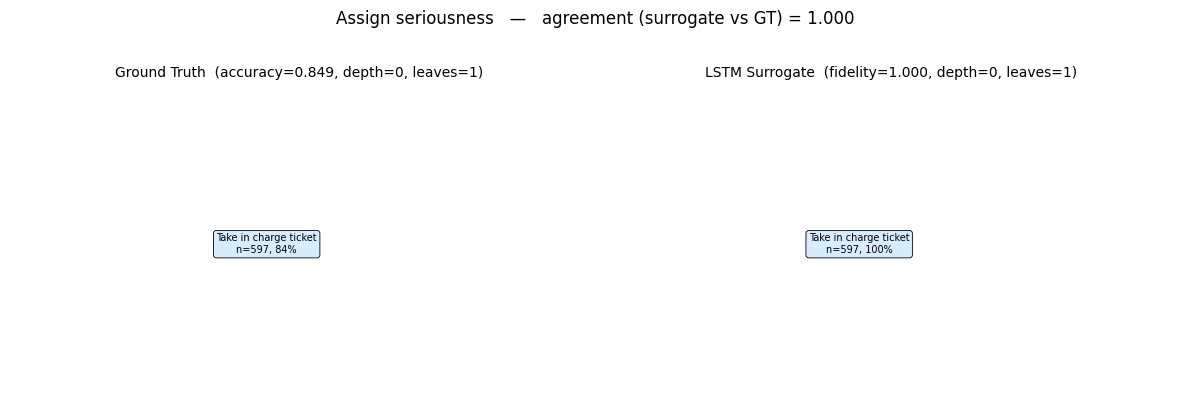

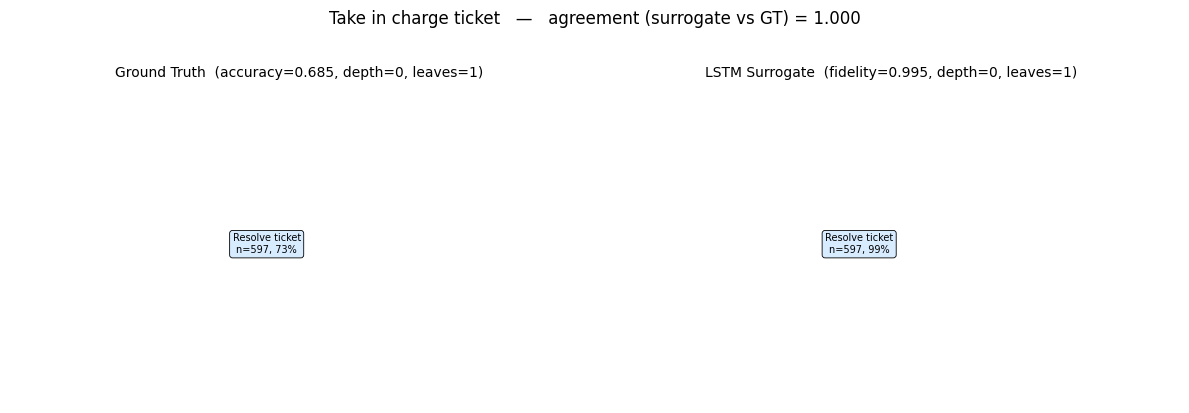

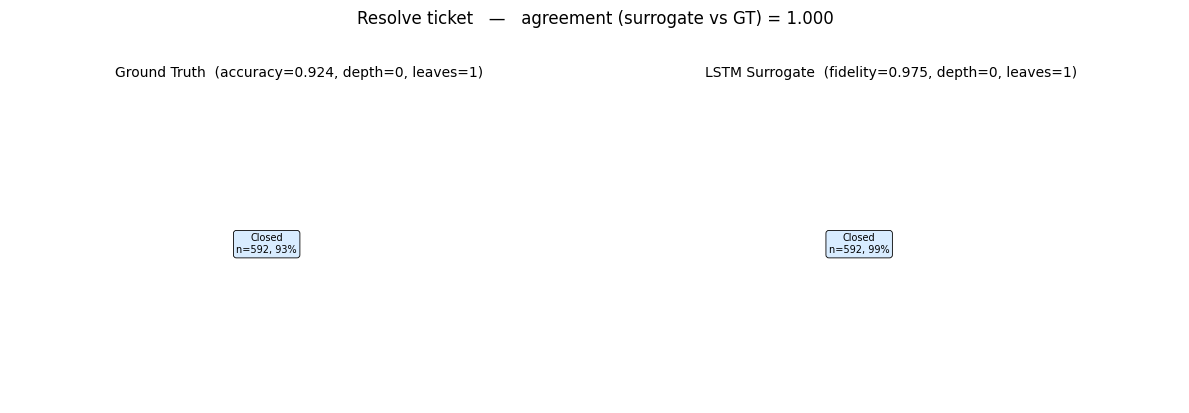

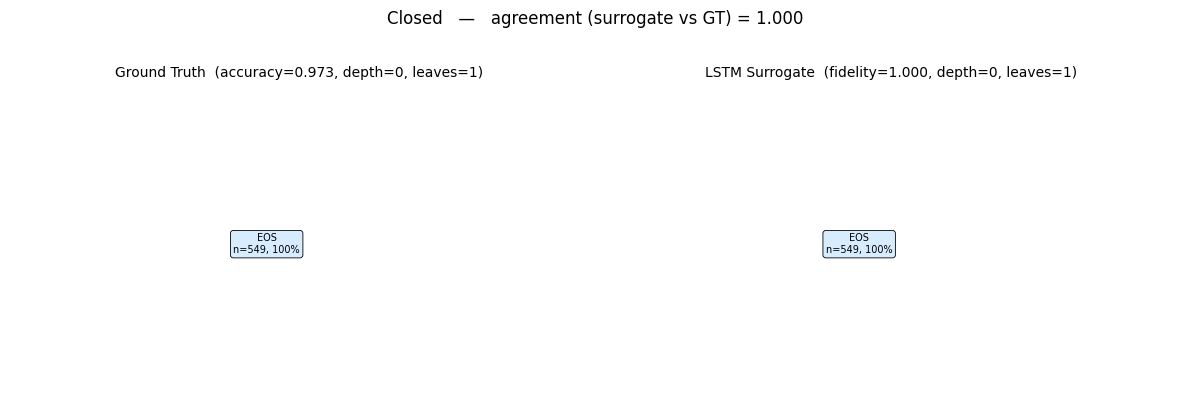

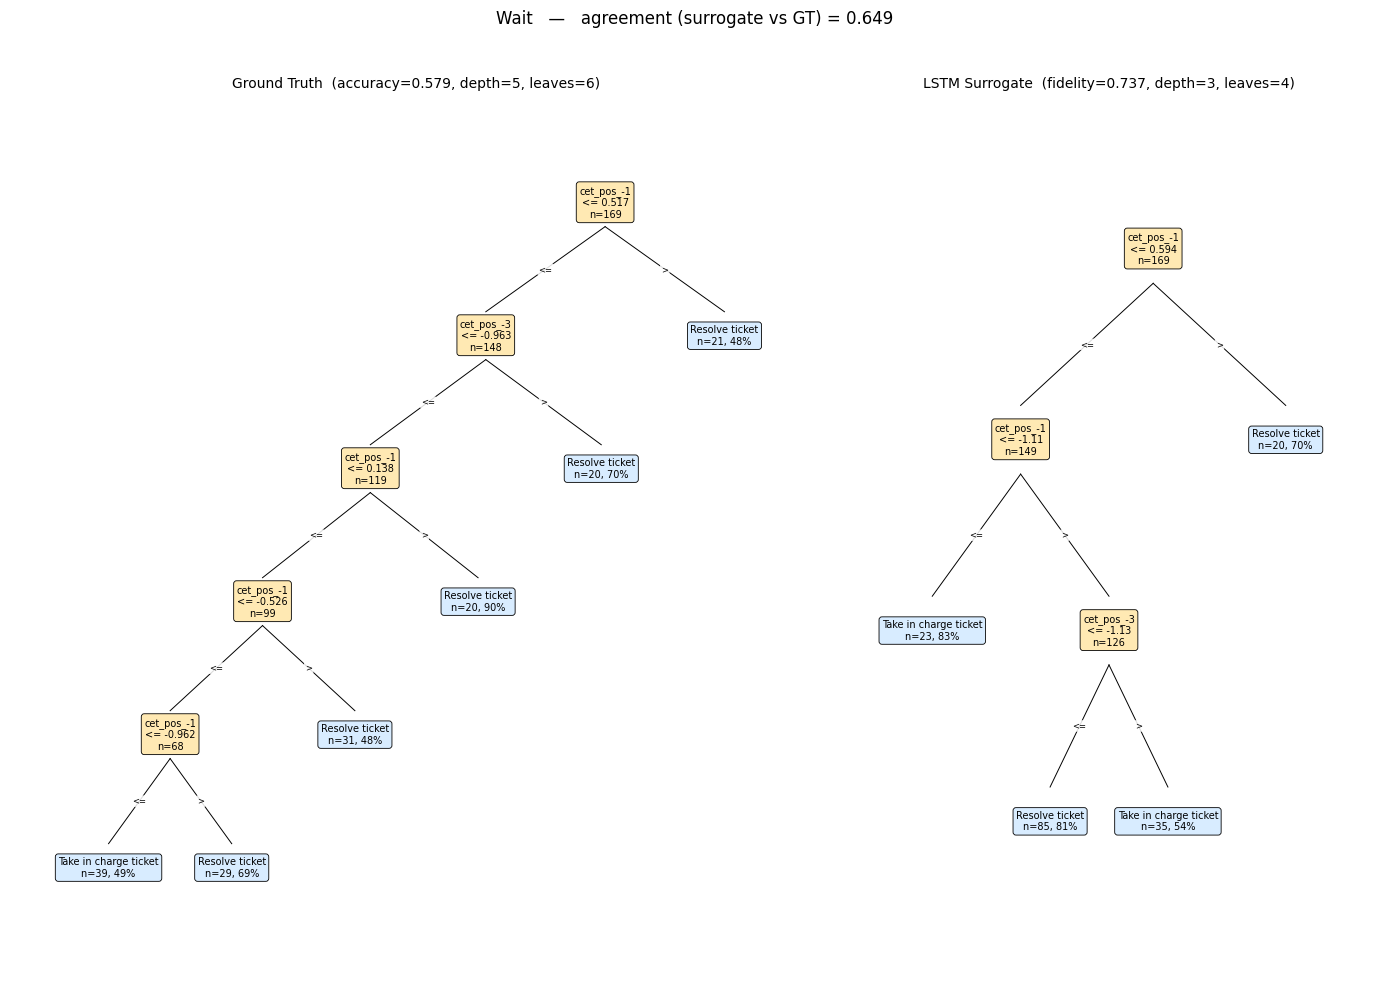

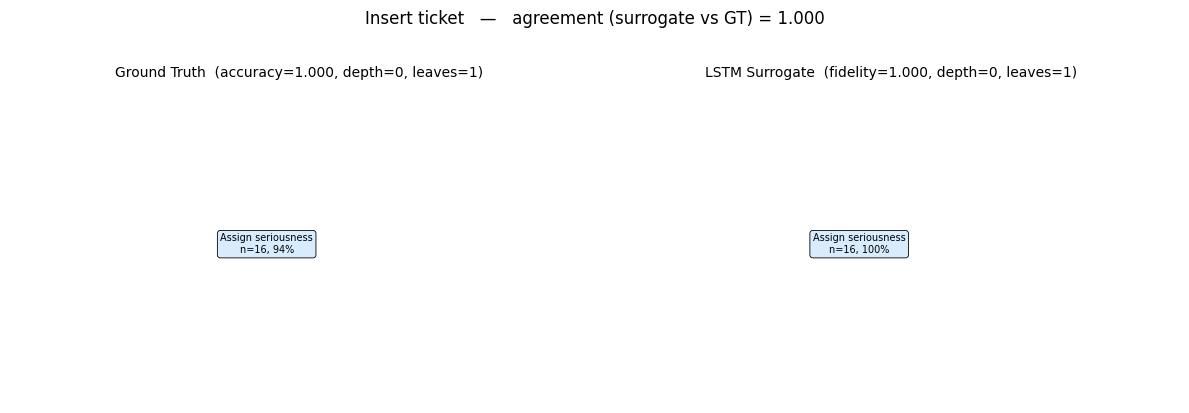

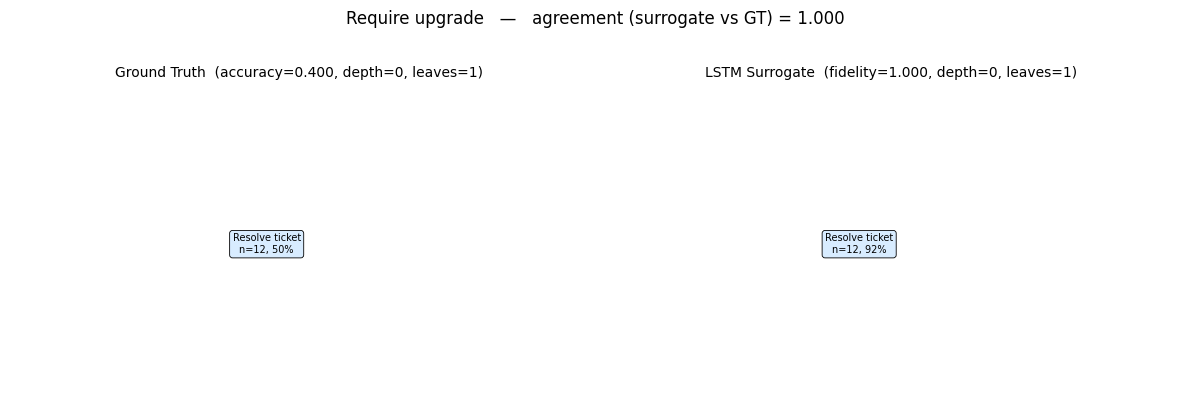

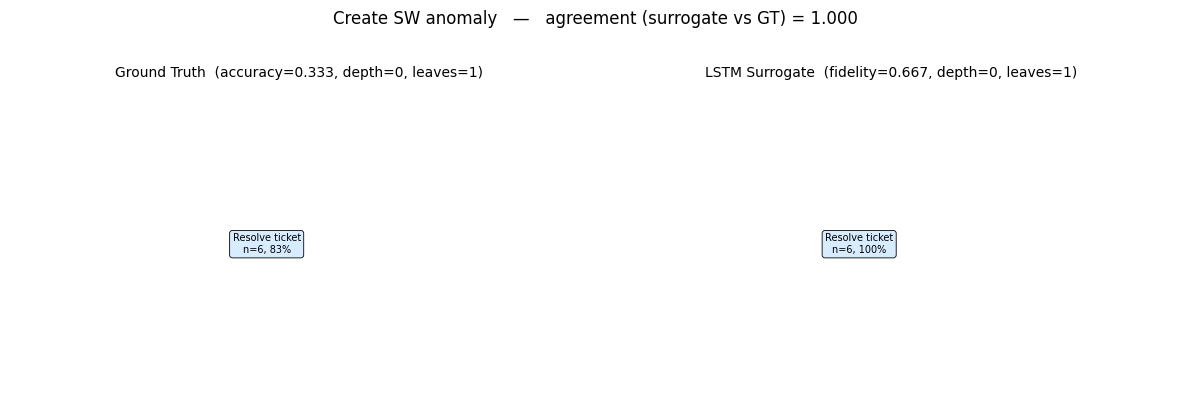

In [7]:
import matplotlib.pyplot as plt


def plot_c45_tree_ax(clf, ax, title=''):
    """Render a C4.5 tree into a given matplotlib axis. Same layout as henryk notebook 22."""
    root = clf.root_
    if root is None:
        return

    positions = {}
    leaf_counter = [0]

    def assign_x(node, depth):
        if not node.children:
            positions[id(node)] = (leaf_counter[0], -depth)
            leaf_counter[0] += 1
            return positions[id(node)][0]
        child_xs = [assign_x(c, depth + 1) for c in node.children]
        x = (min(child_xs) + max(child_xs)) / 2.0
        positions[id(node)] = (x, -depth)
        return x

    assign_x(root, 0)
    max_depth = clf.get_depth()
    n_leaves = clf.get_n_leaves()

    def fmt_cat_label(lbl):
        if isinstance(lbl, (list, tuple, set, frozenset)):
            vals = [str(v) for v in lbl]
            if len(vals) > 3:
                return '{' + ', '.join(vals[:3]) + f', +{len(vals) - 3}' + '}'
            return '{' + ', '.join(vals) + '}'
        return str(lbl)

    def draw(node):
        x, y = positions[id(node)]
        is_leaf = not node.children
        if is_leaf:
            total = sum(node.class_distribution.values())
            conf = (node.class_distribution.get(node.majority_class, 0) / total) if total else 0
            text = f'{node.majority_class}\nn={node.n_samples}, {conf:.0%}'
            color = '#d8ecff'
        else:
            if node.is_categorical:
                text = f'{node.feature}\nn={node.n_samples}'
            else:
                text = f'{node.feature}\n<= {node.threshold:.3g}\nn={node.n_samples}'
            color = '#ffe9b3'
        ax.text(x, y, text, ha='center', va='center', fontsize=7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color,
                          edgecolor='black', linewidth=0.6))
        if is_leaf:
            return
        for i, child in enumerate(node.children):
            cx, cy = positions[id(child)]
            ax.plot([x, cx], [y - 0.18, cy + 0.18], 'k-', lw=0.7)
            if node.is_categorical:
                lbl = node.branch_labels[i] if i < len(node.branch_labels) else str(i)
                edge_text = fmt_cat_label(lbl)
            else:
                edge_text = '<=' if i == 0 else '>'
            mx, my = (x + cx) / 2, (y + cy) / 2
            ax.text(mx, my, edge_text, fontsize=6, ha='center', va='center',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                              edgecolor='none', alpha=0.85))
            draw(child)

    draw(root)
    ax.set_xlim(-0.8, max(n_leaves - 0.2, 1.0))
    ax.set_ylim(-max_depth - 0.8, 0.8)
    ax.set_axis_off()
    if title:
        ax.set_title(title, fontsize=10)


for gateway_act, gr in gateway_results.items():
    gt_clf = gr['clf_gt']
    surr_clf = gr['clf_lstm']

    gt_leaves = max(gt_clf.get_n_leaves(), 1)
    surr_leaves = max(surr_clf.get_n_leaves(), 1)
    gt_depth = gt_clf.get_depth()
    surr_depth = surr_clf.get_depth()

    max_depth = max(gt_depth, surr_depth)
    fig_w = min(32, max(12, (gt_leaves + surr_leaves) * 1.4))
    fig_h = min(18, max(4, (max_depth + 1) * 1.6))

    fig, axes = plt.subplots(
        1, 2, figsize=(fig_w, fig_h),
        gridspec_kw={'width_ratios': [gt_leaves, surr_leaves]},
    )

    plot_c45_tree_ax(
        gt_clf, axes[0],
        title=f'Ground Truth  (accuracy={gr["gt_acc"]:.3f}, '
              f'depth={gt_depth}, leaves={gt_clf.get_n_leaves()})'
    )
    plot_c45_tree_ax(
        surr_clf, axes[1],
        title=f'LSTM Surrogate  (fidelity={gr["fidelity"]:.3f}, '
              f'depth={surr_depth}, leaves={surr_clf.get_n_leaves()})'
    )
    fig.suptitle(
        f'{gateway_act}   —   agreement (surrogate vs GT) = {gr["agreement"]:.3f}',
        fontsize=12, y=1.02,
    )
    plt.tight_layout()
    plt.show()